In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/System-Threat-Forecaster/sample_submission.csv
/kaggle/input/System-Threat-Forecaster/train.csv
/kaggle/input/System-Threat-Forecaster/test.csv


# Importing Dependencies

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import scipy.stats as stats
from scipy.stats import skew, randint, uniform

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_score, recall_score, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OrdinalEncoder, QuantileTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.feature_selection import RFE

In [3]:
pd.options.display.max_rows = None
pd.options.display.max_columns = None

# Load Data

In [4]:
train_data = pd.read_csv("/kaggle/input/System-Threat-Forecaster/train.csv")
test_data = pd.read_csv("/kaggle/input/System-Threat-Forecaster/test.csv")

# Exploratory Data Analysis

In [5]:
train_data.shape

(100000, 76)

In [6]:
test_data.shape

(10000, 75)

In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 76 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   MachineID                           100000 non-null  object 
 1   ProductName                         100000 non-null  object 
 2   EngineVersion                       100000 non-null  object 
 3   AppVersion                          100000 non-null  object 
 4   SignatureVersion                    100000 non-null  object 
 5   IsBetaUser                          100000 non-null  int64  
 6   RealTimeProtectionState             99934 non-null   float64
 7   IsPassiveModeEnabled                100000 non-null  int64  
 8   AntivirusConfigID                   99924 non-null   float64
 9   NumAntivirusProductsInstalled       99924 non-null   float64
 10  NumAntivirusProductsEnabled         99924 non-null   float64
 11  HasTpm                     

In [8]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 75 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   MachineID                           10000 non-null  object 
 1   ProductName                         10000 non-null  object 
 2   EngineVersion                       10000 non-null  object 
 3   AppVersion                          10000 non-null  object 
 4   SignatureVersion                    10000 non-null  object 
 5   IsBetaUser                          10000 non-null  int64  
 6   RealTimeProtectionState             9991 non-null   float64
 7   IsPassiveModeEnabled                10000 non-null  int64  
 8   AntivirusConfigID                   9998 non-null   float64
 9   NumAntivirusProductsInstalled       9998 non-null   float64
 10  NumAntivirusProductsEnabled         9998 non-null   float64
 11  HasTpm                              10000 

In [9]:
train_data.describe()

,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,OSBuildNumber,OSProductSuite,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,InternalBatteryNumberOfCharges,OSBuildNumberOnly,OSBuildRevisionOnly,OSInstallLanguageID,OSUILocaleID,IsPortableOS,IsFlightsDisabled,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,target
count,100000.0,99934.000000,100000.000000,99924.000000,99924.000000,99924.000000,100000.000000,100000.000000,99377.000000,100000.000000,100000.000000,100000.000000,100000.000000,99924.000000,100000.0,99019.000000,99893.000000,99834.000000,99981.000000,99788.000000,99772.000000,99915.000000,99915.000000,99915.000000,9.989000e+04,9.989000e+04,100000.00000,99849.000000,99928.000000,99928.000000,99928.000000,9.948500e+04,100000.000000,100000.000000,99887.000000,100000.000000,100000.000000,99674.0,99624.000000,99666.000000,100000.000000,99980.000000,100000.000000,100000.000000,99866.000000,99441.000000,99441.000000,100000.000000
mean,0.0,6.848430,0.017620,47975.710440,1.326528,1.018264,0.996780,108.078790,81029.938587,169.741630,122.695100,15917.208720,578.403380,0.955326,0.0,0.000505,124.053848,0.980067,0.996569,2209.573265,238780.914154,4.011500,4.530711,2367.693069,5.158619e+05,3.819905e+05,0.08140,6132.087442,16.708674,1552.230416,898.253192,1.118069e+09,15990.596350,986.531360,14.519267,60.030870,0.000520,0.0,401.987613,32942.648044,0.495690,0.003841,0.128470,0.040580,0.058398,0.296668,7.875866,0.505250
std,0.0,1.015166,0.131566,13803.321533,0.520681,0.155291,0.056654,63.062151,48944.027074,89.188929,69.242252,1943.421132,247.240971,0.206588,0.0,0.022466,33.535395,0.139771,0.266669,1300.863891,71708.483379,2.033075,1.288050,837.822392,3.525624e+05,3.246240e+05,0.27345,4813.882548,6.031598,363.438980,213.695880,1.884682e+09,1810.756601,2971.429862,10.142233,44.715508,0.022798,0.0,221.318891,21151.970827,0.499984,0.061855,0.334614,0.197316,0.234496,0.456791,4.562533,0.499975
min,0.0,0.000000,0.000000,39.000000,1.000000,0.000000,0.000000,1.000000,7.000000,1.000000,1.000000,7601.000000,16.000000,0.000000,0.0,0.000000,39.000000,0.000000,0.000000,46.000000,22.000000,1.000000,1.000000,3.000000,1.228800e+04,1.088000e+04,0.00000,512.000000,5.300000,400.000000,300.000000,0.000000e+00,10240.000000,0.000000,1.000000,5.000000,0.000000,0.0,2.000000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.0,7.000000,0.000000,49480.000000,1.000000,1.000000,1.000000,51.000000,36694.000000,89.000000,74.000000,16299.000000,256.000000,1.000000,0.0,0.000000,111.000000,1.000000,1.000000,1443.000000,189586.000000,2.000000,5.000000,1998.000000,2.441980e+05,1.208410e+05,0.00000,4096.000000,13.900000,1366.000000,768.000000,0.000000e+00,16299.000000,167.000000,8.000000,31.000000,0.000000,0.0,142.000000,13020.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
50%,0.0,7.000000,0.000000,53447.000000,1.000000,1.000000,1.000000,97.000000,82373.000000,181.000000,88.000000,16299.000000,768.000000,1.000000,0.0,0.000000,135.000000,1.000000,1.000000,2102.000000,246528.000000,4.000000,5.000000,2503.000000,4.769400e+05,2.567655e+05,0.00000,4096.000000,15.500000,1366.000000,768.000000,0.000000e+00,16299.000000,285.000000,9.000000,34.000000,0.000000,0.0,500.000000,33066.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000
75%,0.0,7.000000,0.000000,53447.000000,2.000000,1.000000,1.000000,162.000000,122835.000000,267.000000,182

In [10]:
test_data.describe()

,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,OSBuildNumber,OSProductSuite,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,InternalBatteryNumberOfCharges,OSBuildNumberOnly,OSBuildRevisionOnly,OSInstallLanguageID,OSUILocaleID,IsPortableOS,IsFlightsDisabled,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier
count,10000.0,9991.000000,10000.000000,9998.00000,9998.000000,9998.000000,10000.00000,10000.000000,9939.000000,9999.000000,10000.00000,10000.000000,10000.000000,9998.000000,10000.0,9908.000000,9990.000000,9984.000000,10000.000000,9982.000000,9979.000000,9989.000000,9989.000000,9989.000000,9.990000e+03,9.990000e+03,10000.00000,9988.000000,9994.000000,9994.000000,9994.000000,9.946000e+03,10000.000000,10000.000000,9986.000000,10000.000000,10000.000000,9965.0,9968.000000,9971.000000,10000.000000,9993.000000,10000.000000,10000.000000,9988.000000,9938.000000,9938.000000
mean,0.0,6.848864,0.017400,48122.25075,1.327065,1.019004,0.99620,107.675900,80985.386055,168.507151,123.50300,15912.849500,577.947200,0.957692,0.0,0.000908,124.040541,0.981971,0.995000,2195.828591,238201.393025,4.007208,4.523175,2368.741816,5.154108e+05,3.793902e+05,0.07650,6150.151982,16.635391,1550.019212,897.198219,1.097277e+09,15986.587700,986.761700,14.689565,60.902600,0.000500,0.0,404.363864,33258.776853,0.505800,0.003202,0.131000,0.041200,0.056468,0.301067,7.906219
std,0.0,1.014203,0.130763,13611.92055,0.524149,0.157627,0.06153,63.268649,49085.060889,89.279554,69.76074,1939.189651,247.370759,0.201302,0.0,0.030127,33.857978,0.133062,0.070537,1291.726213,72020.841935,2.006434,1.297925,840.257504,3.482613e+05,3.162358e+05,0.26581,4536.675978,5.711076,356.275434,210.240813,1.873260e+09,1802.151077,2959.945273,10.237616,45.251103,0.022356,0.0,220.361535,21239.190886,0.499991,0.056501,0.337417,0.198762,0.230834,0.458745,4.522045
min,0.0,0.000000,0.000000,645.00000,1.000000,0.000000,0.00000,1.000000,41.000000,1.000000,2.00000,7601.000000,256.000000,0.000000,0.0,0.000000,41.000000,0.000000,0.000000,245.000000,180.000000,1.000000,1.000000,19.000000,1.480000e+04,1.314900e+04,0.00000,512.000000,5.500000,640.000000,400.000000,0.000000e+00,10240.000000,0.000000,1.000000,5.000000,0.000000,0.0,93.000000,737.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.0,7.000000,0.000000,49480.00000,1.000000,1.000000,1.00000,50.000000,36164.000000,89.000000,74.00000,16299.000000,256.000000,1.000000,0.0,0.000000,111.000000,1.000000,1.000000,1443.000000,189547.000000,2.000000,5.000000,1998.000000,2.441980e+05,1.208420e+05,0.00000,4096.000000,13.900000,1366.000000,768.000000,0.000000e+00,16299.000000,167.000000,8.000000,31.000000,0.000000,0.0,142.000000,13182.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,0.0,7.000000,0.000000,53447.00000,1.000000,1.000000,1.00000,97.000000,82373.000000,181.000000,88.00000,16299.000000,768.000000,1.000000,0.0,0.000000,117.000000,1.000000,1.000000,2102.000000,245824.000000,4.000000,5.000000,2503.000000,4.769400e+05,2.544800e+05,0.00000,4096.000000,15.500000,1366.000000,768.000000,0.000000e+00,16299.000000,285.000000,9.000000,34.000000,0.000000,0.0,500.000000,33075.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000
75%,0.0,7.000000,0.000000,53447.00000,2.000000,1.000000,1.00000,160.000000,122884.500000,258.000000,182.00000,17134.000000,768.000000,1.000000,0.0,0.000000,137.000000,1.000000,1.000000,2668.000000,302837.500000,4.000000,5.0000

In [11]:
train_data.isnull().sum()

MachineID                               0
ProductName                             0
EngineVersion                           0
AppVersion                              0
SignatureVersion                        0
IsBetaUser                              0
RealTimeProtectionState                66
IsPassiveModeEnabled                    0
AntivirusConfigID                      76
NumAntivirusProductsInstalled          76
NumAntivirusProductsEnabled            76
HasTpm                                  0
CountryID                               0
CityID                                623
GeoRegionID                             0
LocaleEnglishNameID                     0
PlatformType                            0
Processor                               0
OSVersion                               0
OSBuildNumber                           0
OSProductSuite                          0
OsPlatformSubRelease                    0
OSBuildLab                              0
SKUEditionName                    

In [12]:
test_data.isnull().sum()

MachineID                              0
ProductName                            0
EngineVersion                          0
AppVersion                             0
SignatureVersion                       0
IsBetaUser                             0
RealTimeProtectionState                9
IsPassiveModeEnabled                   0
AntivirusConfigID                      2
NumAntivirusProductsInstalled          2
NumAntivirusProductsEnabled            2
HasTpm                                 0
CountryID                              0
CityID                                61
GeoRegionID                            1
LocaleEnglishNameID                    0
PlatformType                           0
Processor                              0
OSVersion                              0
OSBuildNumber                          0
OSProductSuite                         0
OsPlatformSubRelease                   0
OSBuildLab                             0
SKUEditionName                         0
IsSystemProtecte

There are no features with high number of null values and thus the null values can be imputed instead of droping the entire feature.

## Checking Class Imbalace for "target" feature

In [13]:
target_counts = train_data['target'].value_counts()

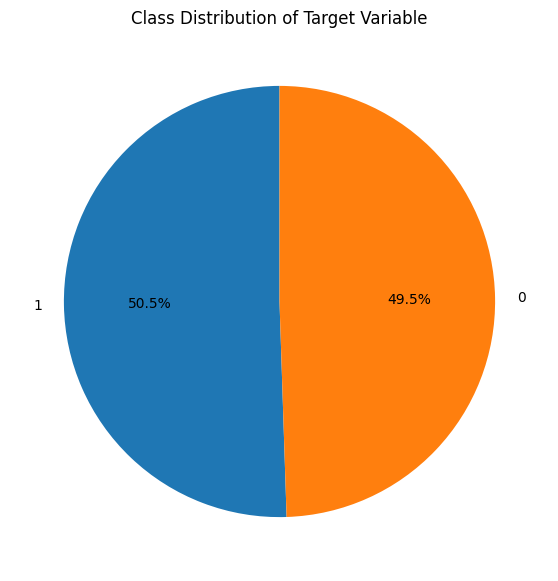

In [14]:
plt.figure(figsize=(7, 7))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle = 90)
plt.title("Class Distribution of Target Variable")
plt.show()

The pie chart represents the class distribution of the target variable in your system threat forecasting training data.
It shows:
* Class 1 (Threat Detected): 50.5%
* Class 0 (No Threats Detected): 49.5%

This balance suggests that the dataset does not suffer from severe class imbalance, which is beneficial for training machine learning models without requiring extensive resampling techniques. This ensures that the model training isn't biased towards a dominant class.

In [15]:
num_cols = train_data.select_dtypes(include=['number']).columns.drop('target', errors='ignore')
cat_cols = train_data.select_dtypes(include=['object', 'category']).columns.drop('MachineID', errors='ignore')

## Computing Correlation Matrix (Handle missing values safely)

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


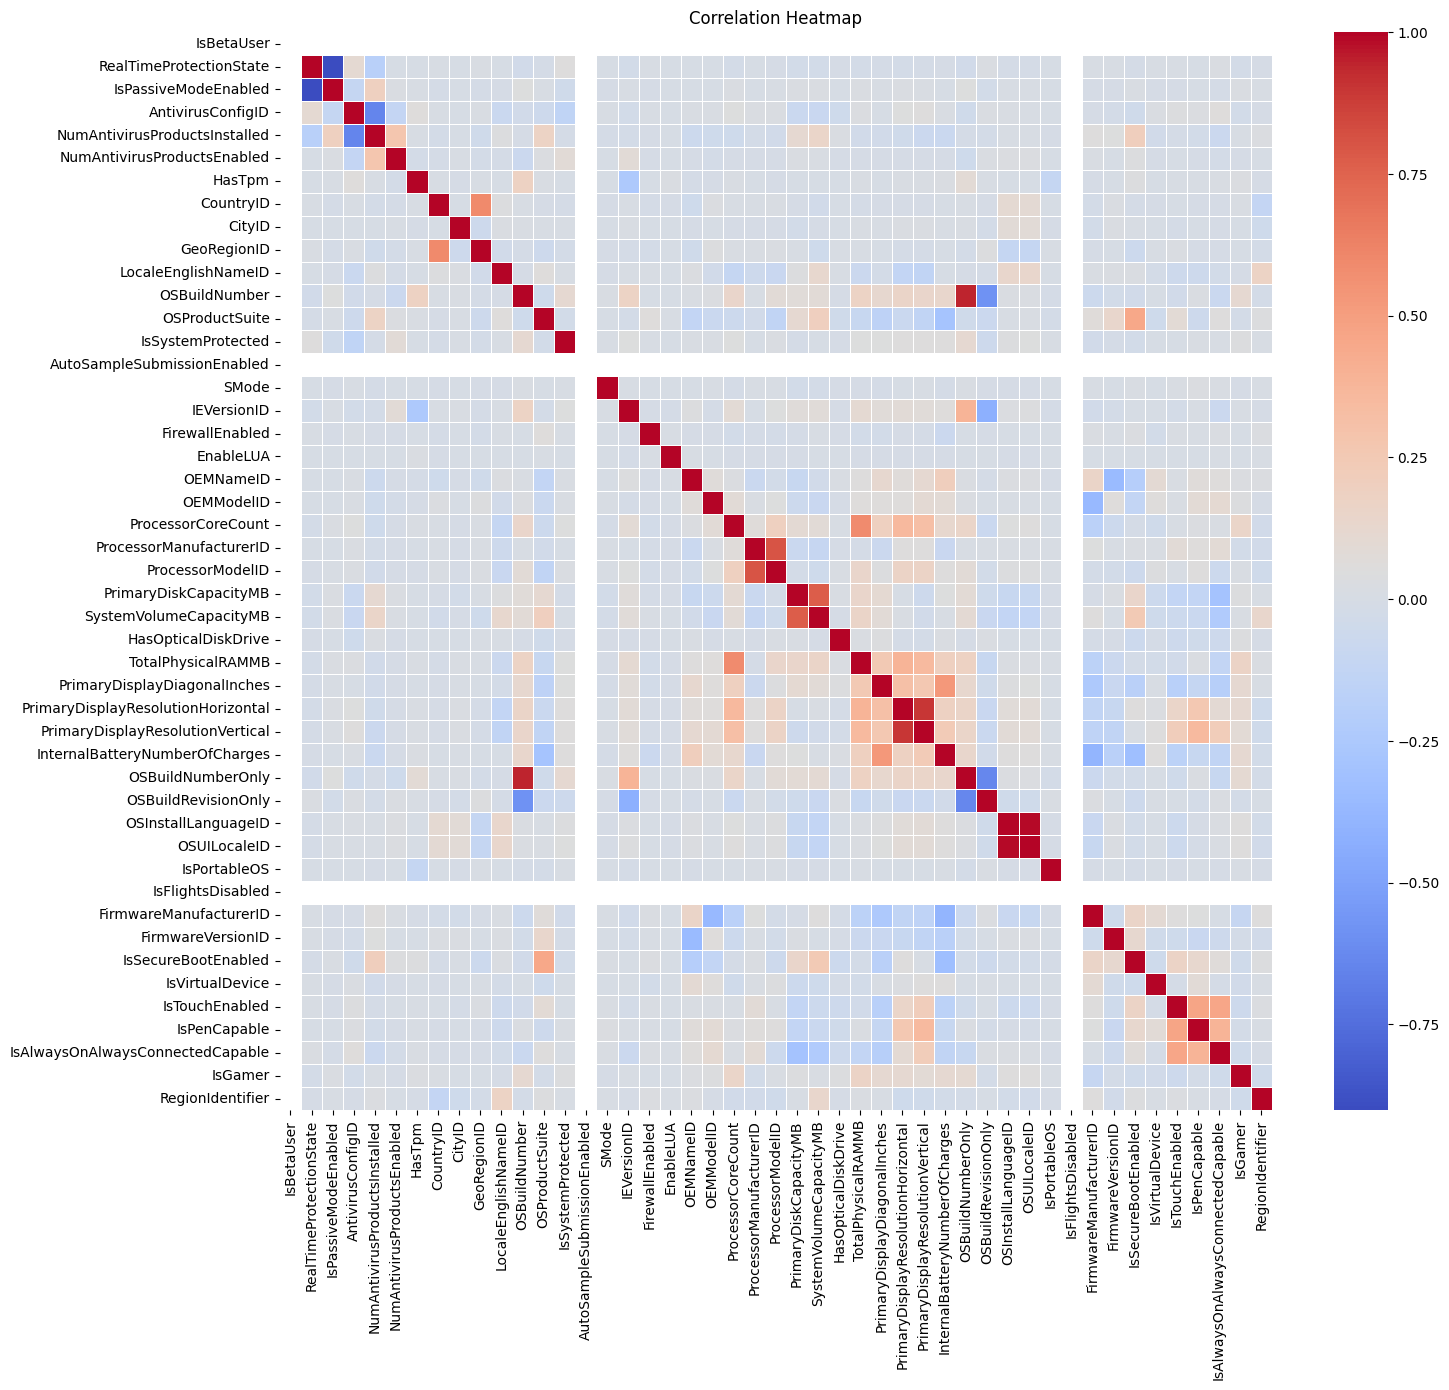

In [16]:
plt.figure(figsize=(16, 14))
corr_matrix = train_data[num_cols].corr()
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

#### The correlation heat-map shows:
* Most of the features have low or negligible correlation with each other, as indicated by the large number of blue and light-colored areas. This suggests that many features are relatively independent.
* Some feature pairs show high positive correlation (in red):
    * PrimaryDisplayResolutionHorizontal and PrimaryDisplayResolutionVertical
    * OSInstallLanguageID and OSUILocaleID
    * OSBuildNumber and OSBuildNumberOnly
    * ProcessorManufacturerID and ProcessorModelID
    * SystemVolumeCapacityMB and PrimaryDiskCapacityMB
* Some feature pairs show high negative correlation (in blue):
    * RealTimeProtectionState and IsPassiveModeEnabled
    * NumAntivirusProductsInstalled and AntivirusConfigID
    * OSBuildNumberOnly and OSRevisionNumberonly

## Scatter Plot: PrimaryDisplayResolutionHorizontal vs. PrimaryDisplayResolutionVertical

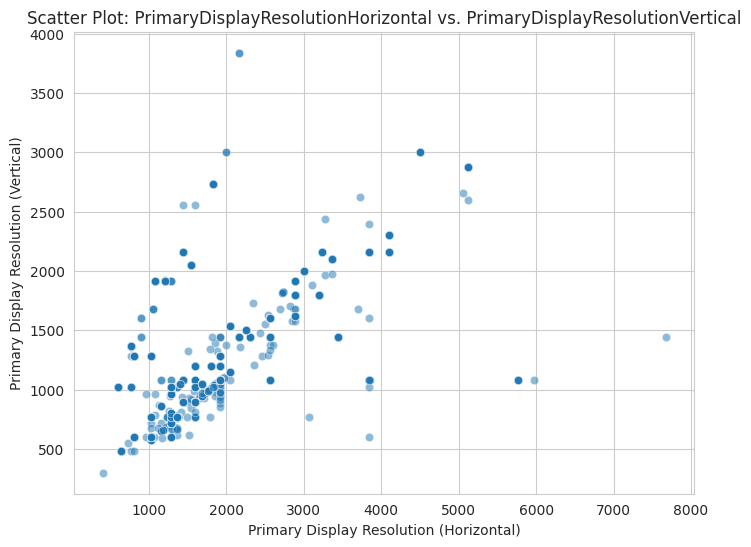

In [17]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=train_data["PrimaryDisplayResolutionHorizontal"], 
                y=train_data["PrimaryDisplayResolutionVertical"], 
                alpha=0.5)

plt.xlabel("Primary Display Resolution (Horizontal)")
plt.ylabel("Primary Display Resolution (Vertical)")
plt.title("Scatter Plot: PrimaryDisplayResolutionHorizontal vs. PrimaryDisplayResolutionVertical")
plt.show()

* The scatter plot shows a strong positive correlation between Primary Display Resolution (Horizontal) and Primary Display Resolution (Vertical). As the horizontal resolution increases, the vertical resolution also tends to increase.
* There are several clusters of points, likely representing common screen resolution standards (e.g., 1920x1080, 1366x768, etc.).These clusters suggest that many devices share standard screen resolutions.
* Some points deviate from the general trend, possibly representing uncommon or ultrawide screen resolutions. These outliers in the high-resolution range could indicate specialized devices (e.g., 4K monitors, gaming setups).

Instead of treating resolution as two separate features, a new feature Primary Display Pixels(Horizontal x Vertical) could be derived.

## Scatter Plot: OSInstallLanguageID vs. OSUILocaleID

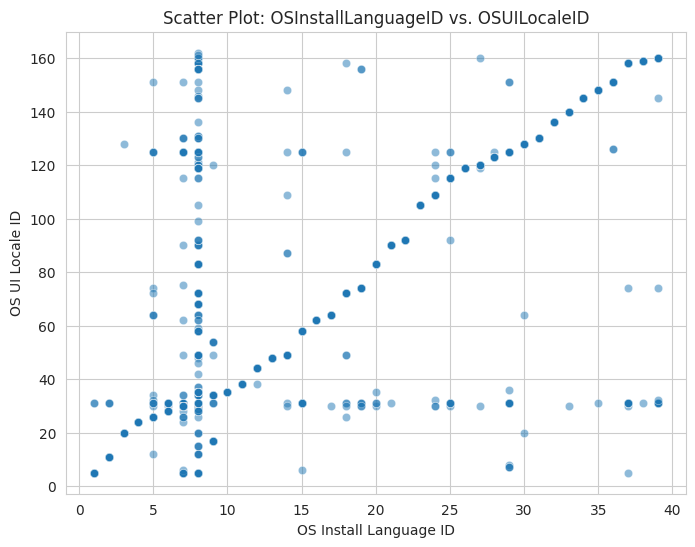

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=train_data["OSInstallLanguageID"], 
                y=train_data["OSUILocaleID"], 
                alpha=0.5)

plt.xlabel("OS Install Language ID")
plt.ylabel("OS UI Locale ID")
plt.title("Scatter Plot: OSInstallLanguageID vs. OSUILocaleID")
plt.show()

* There is a clear diagonal trend where OSInstallLanguageID increases proportionally with OSUILocaleID, indicating that most systems have matching installation language and UI locale settings.
* Vertical Clusters at Certain Install Language IDs indicates several OSInstallLanguageID values have a wide range of OSUILocaleID values.
* Some points deviate from the diagonal trend, indicating systems where the OS installation language and UI locale do not match. This could be due to users installing an OS in one language but later switching to a different UI locale.

Grouping similar language pairs might improve the model’s ability to detect patterns in regional usage.

## Scatter Plot: ProcessorManufacturerID vs. ProcessorModelID

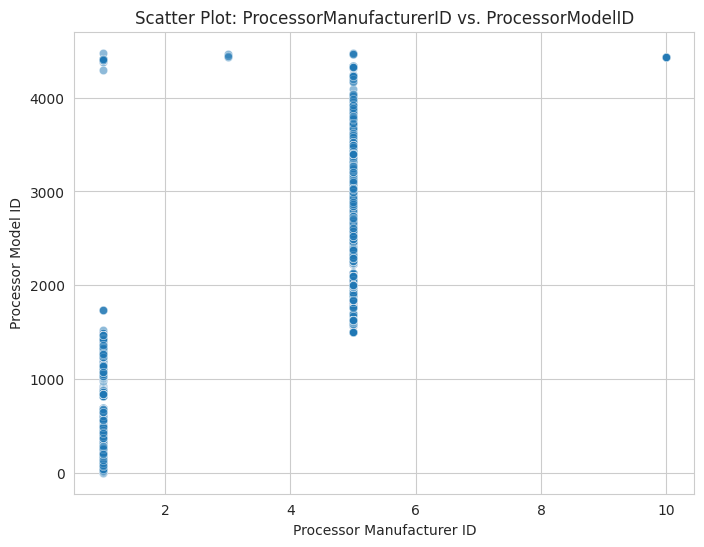

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=train_data["ProcessorManufacturerID"], 
                y=train_data["ProcessorModelID"], 
                alpha=0.5)

plt.xlabel("Processor Manufacturer ID")
plt.ylabel("Processor Model ID")
plt.title("Scatter Plot: ProcessorManufacturerID vs. ProcessorModelID")
plt.show()

* Each ProcessorManufacturerID has a corresponding ProcessorModelID range, forming vertical clusters. This indicates that a single manufacturer produces multiple processor models, and there is little to no overlap between manufacturers.
* The x-axis has only a few discrete values, suggesting a limited number of processor manufacturers.
* Some manufacturers have a much larger variety of processor models than others.


## Scatter Plot: SystemVolumeCapacityMB vs. PrimaryDiskCapacityMB

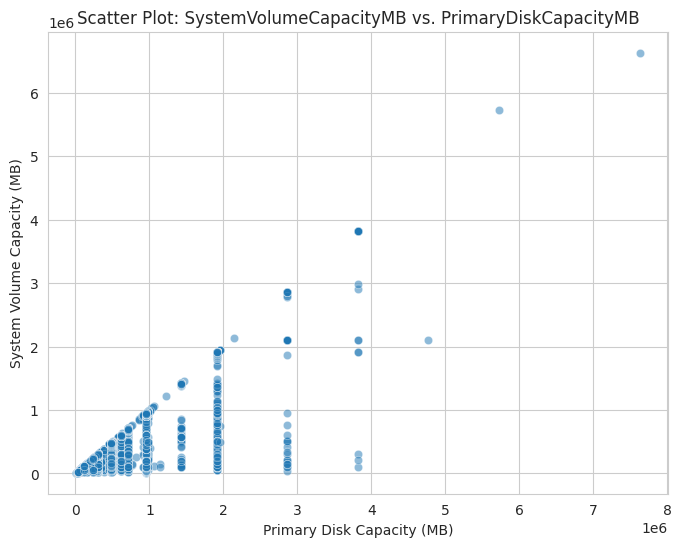

In [20]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=train_data["PrimaryDiskCapacityMB"], 
                y=train_data["SystemVolumeCapacityMB"], 
                alpha=0.5)

plt.xlabel("Primary Disk Capacity (MB)")
plt.ylabel("System Volume Capacity (MB)")
plt.title("Scatter Plot: SystemVolumeCapacityMB vs. PrimaryDiskCapacityMB")
plt.show()

* The plot shows a diagonal pattern where SystemVolumeCapacityMB increases as PrimaryDiskCapacityMB increases. This indicates that as the primary disk capacity increases, the system volume capacity also tends to increase.
* There are noticeable vertical clusters, which suggest that many systems have predefined disk capacity sizes (e.g., 1TB, 2TB, etc.). This could be due to standard storage configurations in machines.
* A few points are significantly higher than others, indicating machines with exceptionally large disk capacities. These could be high-performance or server-grade systems.

Instead of treating  as two separate features, a new feature SystemToPrimaryDiskRatio(SystemVolumeCapacity / PrimaryDiskCapacity) could be derived.

## Box Plot: RealTimeProtectionState vs. IsPassiveModeEnabled

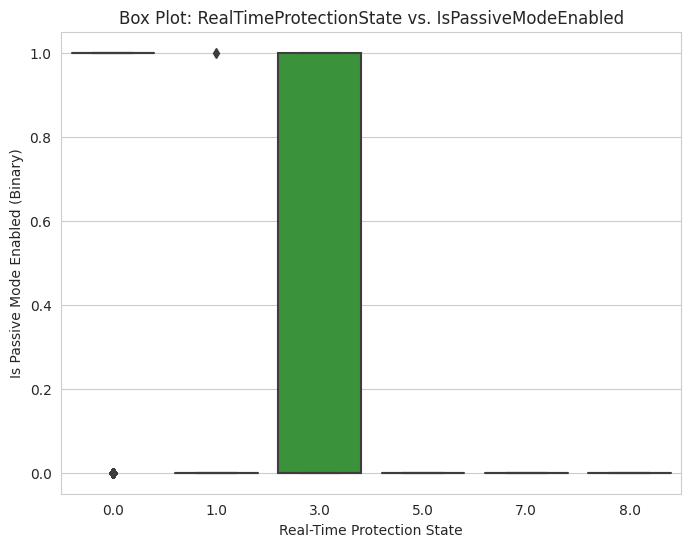

In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=train_data["RealTimeProtectionState"], 
            y=train_data["IsPassiveModeEnabled"].astype(int))

plt.xlabel("Real-Time Protection State")
plt.ylabel("Is Passive Mode Enabled (Binary)")
plt.title("Box Plot: RealTimeProtectionState vs. IsPassiveModeEnabled")
plt.show()

* The plot shows that when RealTimeProtectionState is at certain values (especially 3), IsPassiveModeEnabled is 1 (enabled). When RealTimeProtectionState takes other values (0, 1, 5, 7, etc.), IsPassiveModeEnabled is mostly 0 (disabled).
* A few extreme values appear, which could indicate unusual security configurations or system states.
Instead of treating these as two separate features, a new feature RealTimeProtectionStatetoIsPassiveModeEnabled (RealTimeProtectionState / (IsPassiveModeEnabled + 1)) could be derived.

## Bar Graph for the number of missing data in the Numerical features

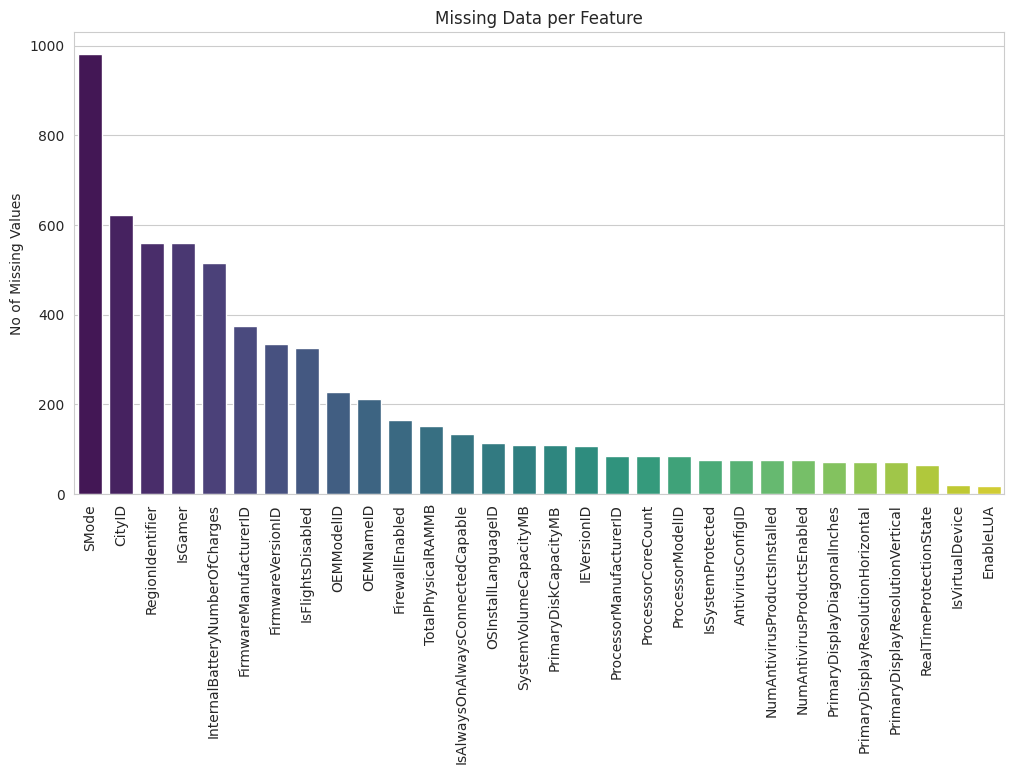

In [22]:
missing_counts = train_data[num_cols].isnull().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_counts.index, y=missing_counts.values, palette="viridis")
plt.xticks(rotation=90)
plt.ylabel("No of Missing Values")
plt.title("Missing Data per Feature")
plt.show()

#### This Bar-Graph shows that:
* SMode has the highest number of missing values among Numerical columns followed by CityID, IsGamer, etc.
* Although the maximum number of missing values are close to 1000, the total number of rows is 1,00,000. Thus, number of missing values are close to 1% of the no. of rows.
* Imputing values would work better rather than droping rows or dropping the whole column with high number of missing values.

## Bar Graph for the number of missing data in the Numerical features

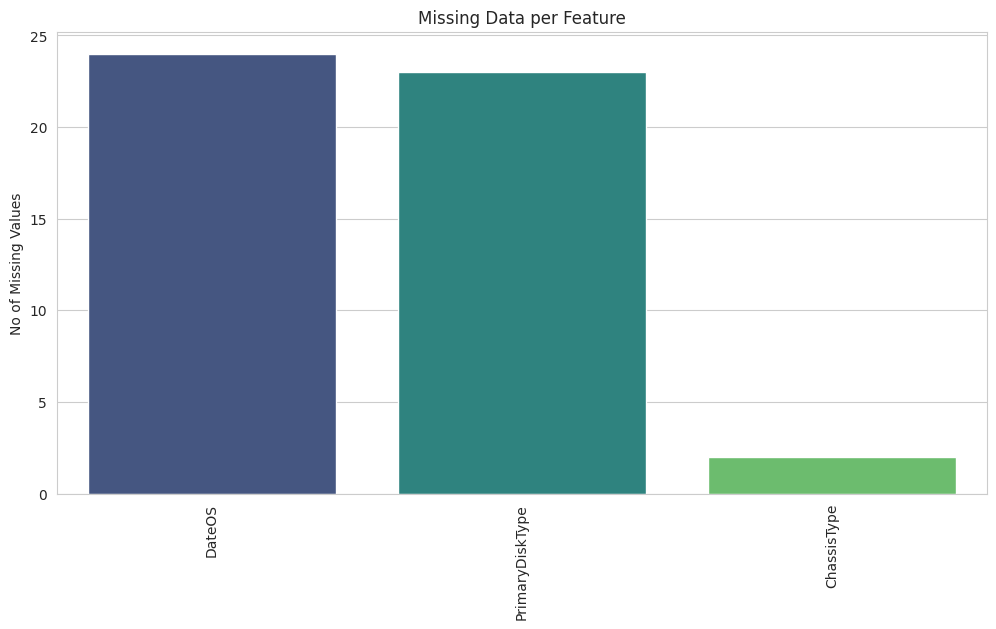

In [23]:
missing_counts = train_data[cat_cols].isnull().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_counts.index, y=missing_counts.values, palette="viridis")
plt.xticks(rotation=90)
plt.ylabel("No of Missing Values")
plt.title("Missing Data per Feature")
plt.show()

#### This Bar-Graph shows that:
* DateOS has the highest number of missing values among Categorical columns followed by PrimaryDiskType, ChassisType.

## Checking missing values percentage

In [24]:
missing_values = train_data[num_cols].isnull().sum()
missing_percent = (missing_values / len(train_data)) * 100
missing_df = pd.DataFrame({"Feature": num_cols, "Missing Percent": missing_percent})
missing_df = missing_df.sort_values(by="Missing Percent", ascending=False)

## Computing skewness of numeric features while avoiding error in constant features

In [25]:
skewness = {}
for col in num_cols:
    if train_data[col].nunique() > 1:
        skewness[col] = skew(train_data[col].dropna())
    else:
        skewness[col] = 0

skew_df = pd.DataFrame({"Features": skewness.keys(), "Skewness": skewness.values()})
skew_df = skew_df.sort_values(by="Skewness", ascending=False)

The skewness formula used by the library scipy.stats.skew is:

$$
\text{Skewness} = \frac{n}{(n-1)(n-2)} \sum_{i=1}^{n} \left( \frac{X_i - \bar{X}}{\sigma} \right)^3
$$

Where:
- $n$ is the number of data points,
- $X_i$ is each data point,
- $\bar{X}$ is the mean of the data,
- $\sigma$ is the standard deviation of the data.

The skewness formula essentially compares the shape of the distribution to a normal distribution, where skewness is zero.

## Plotting skewness distribution in numeric features

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


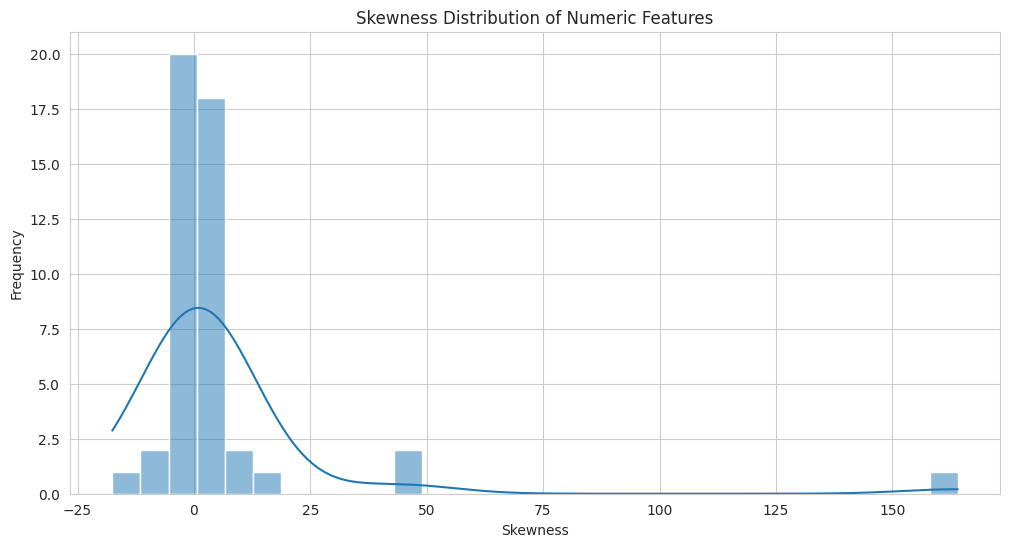

In [26]:
plt.figure(figsize=(12, 6))
sns.histplot(skew_df["Skewness"], bins=30, kde=True)
plt.title("Skewness Distribution of Numeric Features")
plt.xlabel("Skewness")
plt.ylabel("Frequency")
plt.show()

#### The histogram shows the skewness distribution of numeric features in the train dataset:
* Most Features are Close to Zero Skewness: The majority of the features have skewness values near 0, indicating that they are approximately normally distributed. Features with near-zero skewness are easier to work with for machine learning algorithms since they do not require transformation.
* Positive Skewness: A few features exhibit high positive skewness (greater than 50, even up to 150). These features have a long tail to the right, meaning that the data distribution is heavily concentrated on the left with a few extreme values on the right. Highly skewed data may require transformation (e.g., log transformation or Box-Cox transformation) to normalize the distribution.
* Negative Skewness: There are a couple of features with negative skewness (around -25). This indicates that the data is concentrated on the right with a tail extending to the left. Depending on the impact on the model, you may consider transforming these features as well.
* Outliers and Long Tails: The features with high skewness (both positive and negative) might have outliers or long tails, which could negatively impact model performance. Addressing outliers or applying transformations can help improve model accuracy.

# Pre-Processing

## Feature Engineering

### Converting OSGenuineState to Binary (IS_GENUINE = 1 and Others = 0)

#### On Aalyzing the datasets we assume OSGenuineState that IS_GENUINE should less likely be target of class 1.

In [27]:
train_data['OSGenuineState'] = (train_data['OSGenuineState'] == 'IS_GENUINE').astype(int)
test_data['OSGenuineState'] = (test_data['OSGenuineState'] == 'IS_GENUINE').astype(int)

### Converting DateAS and DateOS to date and time

We should extract the Dates in date and time format.

In [28]:
train_data['DateAS'] = pd.to_datetime(train_data['DateAS'], errors='coerce')
train_data['DateOS'] = pd.to_datetime(train_data['DateOS'], errors='coerce')
test_data['DateAS'] = pd.to_datetime(test_data['DateAS'], errors='coerce')
test_data['DateOS'] = pd.to_datetime(test_data['DateOS'], errors='coerce')

### Fill missing DateOS and DateAS with today's date

Filling missing dates with todays date that should help with preprocessing.

In [29]:
train_data['DateOS'] = train_data['DateOS'].fillna(pd.to_datetime('today'))
test_data['DateOS'] = test_data['DateOS'].fillna(pd.to_datetime('today'))
train_data['DateAS'] = train_data['DateAS'].fillna(pd.to_datetime('today'))
test_data['DateAS'] = test_data['DateAS'].fillna(pd.to_datetime('today'))

### Some more Feature Engineering

#### Rows with High correlation are combined.

In [30]:
train_data['PrimaryDisplayPixels'] = train_data['PrimaryDisplayResolutionHorizontal'] * train_data['PrimaryDisplayResolutionVertical']
test_data['PrimaryDisplayPixels'] = test_data['PrimaryDisplayResolutionHorizontal'] * test_data['PrimaryDisplayResolutionVertical']

train_data['OSLocaleAndLanguage'] = train_data['OSInstallLanguageID'].astype(str) + "_" + train_data['OSUILocaleID'].astype(str)
test_data['OSLocaleAndLanguage'] = test_data['OSInstallLanguageID'].astype(str) + "_" + test_data['OSUILocaleID'].astype(str)

train_data['SystemToPrimaryDiskRatio'] = train_data['SystemVolumeCapacityMB'] / (train_data['PrimaryDiskCapacityMB'] + 1)
test_data['SystemToPrimaryDiskRatio'] = test_data['SystemVolumeCapacityMB'] / (test_data['PrimaryDiskCapacityMB'] + 1)

train_data['RealTimeProtectionStatetoIsPassiveModeEnabled'] = train_data['RealTimeProtectionState']/(train_data['IsPassiveModeEnabled'] + 1)
test_data['RealTimeProtectionStatetoIsPassiveModeEnabled'] = test_data['RealTimeProtectionState']/(test_data['IsPassiveModeEnabled'] + 1)

#train_data['Processor'] = train_data['ProcessorManufacturerID'].astype(str) + "_" + train_data['ProcessorModelID'].astype(str)
#test_data['Processor'] = test_data['ProcessorManufacturerID'].astype(str) + "_" + test_data['ProcessorModelID'].astype(str)
#train_data = train_data.drop(columns=['ProcessorManufacturerID', 'ProcessorModelID'], axis=1]
#test_data = test_data.drop(columns=['ProcessorManufacturerID', 'ProcessorModelID'], axis=1]

In [31]:
train_data['AntivirusUsageRatio'] = train_data['NumAntivirusProductsEnabled'] / (train_data['NumAntivirusProductsInstalled'] + 1)
test_data['AntivirusUsageRatio'] = test_data['NumAntivirusProductsEnabled'] / (test_data['NumAntivirusProductsInstalled'] + 1)

train_data['DiskToRAMRatio'] = train_data['PrimaryDiskCapacityMB'] / (train_data['TotalPhysicalRAMMB'] + 1)
test_data['DiskToRAMRatio'] = test_data['PrimaryDiskCapacityMB'] / (test_data['TotalPhysicalRAMMB'] + 1)

train_data['RAM_per_Core'] = train_data['TotalPhysicalRAMMB'] / (train_data['ProcessorCoreCount'] + 1)
test_data['RAM_per_Core'] = test_data['TotalPhysicalRAMMB'] / (test_data['ProcessorCoreCount'] + 1)

train_data['Disk_per_Core'] = train_data['PrimaryDiskCapacityMB'] / (train_data['ProcessorCoreCount'] + 1)
test_data['Disk_per_Core'] = test_data['PrimaryDiskCapacityMB'] / (test_data['ProcessorCoreCount'] + 1)

train_data['Multiple_Antivirus'] = (train_data['NumAntivirusProductsInstalled'] > 1).astype(int)
test_data['Multiple_Antivirus'] = (test_data['NumAntivirusProductsInstalled'] > 1).astype(int)

train_data['Security_Score'] = (train_data[['IsBetaUser', 'RealTimeProtectionState', 'IsSystemProtected', 'AutoSampleSubmissionEnabled', 'FirewallEnabled', 'EnableLUA']].fillna(0).sum(axis=1))
test_data['Security_Score'] = (test_data[['IsBetaUser', 'RealTimeProtectionState', 'IsSystemProtected', 'AutoSampleSubmissionEnabled', 'FirewallEnabled', 'EnableLUA']].fillna(0).sum(axis=1))

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


In [32]:
train_data['OS_last_updated'] = (pd.to_datetime('today') - train_data['DateOS']).dt.days.fillna(0)
test_data['OS_last_updated'] = (pd.to_datetime('today') - test_data['DateOS']).dt.days.fillna(0)

train_data['Malware_signature_dates'] = (train_data['DateAS'] - train_data['DateOS']).dt.days.fillna(0)
test_data['Malware_signature_dates'] = (test_data['DateAS'] - test_data['DateOS']).dt.days.fillna(0)

#### Removing columns with high correlation with other columns to reduce redundancy

In [33]:
train_data = train_data.drop(columns=['DateAS', 'DateOS', 'SystemVolumeCapacityMB', 'PrimaryDiskCapacityMB', 'OSInstallLanguageID', 'OSUILocaleID',
                                     'PrimaryDisplayResolutionHorizontal', 'PrimaryDisplayResolutionVertical', 'RealTimeProtectionState', 
                                      'IsPassiveModeEnabled', 'OSBuildNumberOnly', 'IsBetaUser','AutoSampleSubmissionEnabled','IsFlightsDisabled'], axis=1)
test_data = test_data.drop(columns=['DateAS', 'DateOS', 'SystemVolumeCapacityMB', 'PrimaryDiskCapacityMB', 'OSInstallLanguageID', 'OSUILocaleID',
                                    'PrimaryDisplayResolutionHorizontal', 'PrimaryDisplayResolutionVertical', 'RealTimeProtectionState', 
                                    'IsPassiveModeEnabled', 'OSBuildNumberOnly', 'IsBetaUser','AutoSampleSubmissionEnabled','IsFlightsDisabled'], axis=1)

In [34]:
train_data.shape

(100000, 74)

In [35]:
test_data.shape

(10000, 73)

Train data has an extra column, that is, the Target column.

In [36]:
num_cols = train_data.select_dtypes(include=['number']).columns.drop('target', errors='ignore')
cat_cols = train_data.select_dtypes(include=['object', 'category']).columns.drop('MachineID', errors='ignore')

## Detecting Binary Categorical columns if any

In [37]:
binary_features_cat = []
for col in cat_cols:
    unique_values = train_data[col].dropna().unique()
    if len(unique_values) == 2:
        binary_features_cat.append(col)

print(f"Binary Features: {binary_features_cat}")

Binary Features: ['ProductName', 'DeviceFamily']


### Converting Binary Categorical columns to Binary Digits

In [38]:
for col in binary_features_cat:
    train_data[col] = pd.Categorical(train_data[col]).codes
    test_data[col] = pd.Categorical(test_data[col], categories=train_data[col].unique()).codes 

In [39]:
num_cols = train_data.select_dtypes(include=['number']).columns.drop('target', errors='ignore')
cat_cols = train_data.select_dtypes(include=['object', 'category']).columns.drop('MachineID', errors='ignore')

## Detecting Binary Features in Numeric Columns

In [40]:
binary_features_num = []
for col in num_cols:
    unique_values = train_data[col].dropna().unique()
    if len(unique_values) == 2:
        binary_features_num.append(col)

print(f"Binary Features: {binary_features_num}")

Binary Features: ['ProductName', 'HasTpm', 'IsSystemProtected', 'SMode', 'FirewallEnabled', 'DeviceFamily', 'HasOpticalDiskDrive', 'IsPortableOS', 'OSGenuineState', 'IsSecureBootEnabled', 'IsVirtualDevice', 'IsTouchEnabled', 'IsPenCapable', 'IsAlwaysOnAlwaysConnectedCapable', 'IsGamer', 'Multiple_Antivirus']


## Non Binary Features in Numeric Columns

In [41]:
non_binary_features = [col for col in num_cols if col not in binary_features_num]
print(f"Non-binary Features: {non_binary_features}")

Non-binary Features: ['AntivirusConfigID', 'NumAntivirusProductsInstalled', 'NumAntivirusProductsEnabled', 'CountryID', 'CityID', 'GeoRegionID', 'LocaleEnglishNameID', 'OSBuildNumber', 'OSProductSuite', 'IEVersionID', 'EnableLUA', 'OEMNameID', 'OEMModelID', 'ProcessorCoreCount', 'ProcessorManufacturerID', 'ProcessorModelID', 'TotalPhysicalRAMMB', 'PrimaryDisplayDiagonalInches', 'InternalBatteryNumberOfCharges', 'OSBuildRevisionOnly', 'FirmwareManufacturerID', 'FirmwareVersionID', 'RegionIdentifier', 'PrimaryDisplayPixels', 'SystemToPrimaryDiskRatio', 'RealTimeProtectionStatetoIsPassiveModeEnabled', 'AntivirusUsageRatio', 'DiskToRAMRatio', 'RAM_per_Core', 'Disk_per_Core', 'Security_Score', 'OS_last_updated', 'Malware_signature_dates']


## 

## Detecting Highly skewed features

In [42]:
skewness = train_data[non_binary_features].apply(skew)
skewed_features = skewness[abs(skewness) > 2].index.tolist()

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


Highly skewed features should be transformed using Quantile Transformer for making them normaly distributed.

In [43]:
skewed_features

['OSBuildNumber', 'OSBuildRevisionOnly', 'Security_Score']

## Detecting and ploting outliers in Numerical Non Binary Features

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


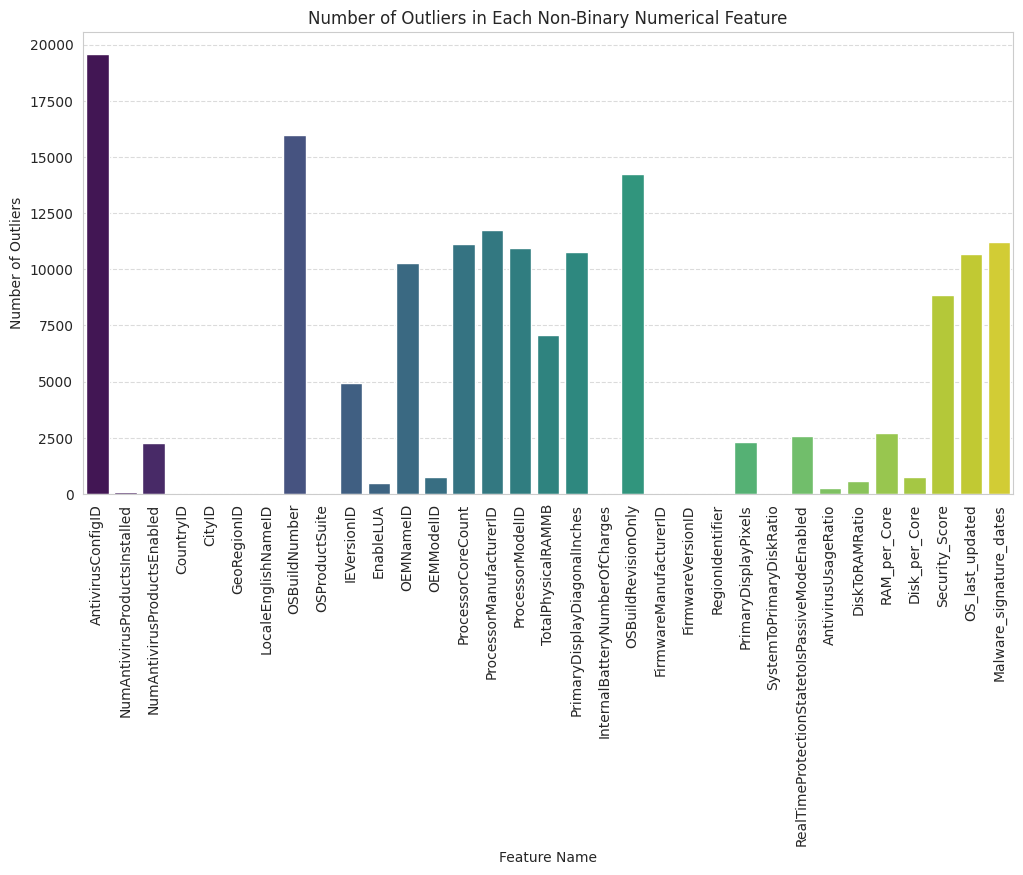

In [44]:
def count_outliers_iqr(df, numerical_features):
    Q1 = df[numerical_features].quantile(0.25)
    Q3 = df[numerical_features].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[numerical_features] < lower_bound) | (df[numerical_features] > upper_bound)).sum()
    return outliers

outlier_counts = count_outliers_iqr(train_data, non_binary_features)

plt.figure(figsize=(12, 6))
sns.barplot(x=outlier_counts.index, y=outlier_counts.values, palette="viridis")
plt.xticks(rotation=90) 
plt.xlabel("Feature Name")
plt.ylabel("Number of Outliers")
plt.title("Number of Outliers in Each Non-Binary Numerical Feature")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

####   1. Features with the Highest Outliers
* AntivirusConfigID (~19,500 outliers)
  * Extremely high number of outliers, suggesting a skewed or highly imbalanced distribution.
  * This might be due to unique antivirus configurations rarely occurring in the dataset.
* GeoRegionID (~15,000 outliers)
  * Indicates that certain geographical regions are significantly different from the majority of the data.
  * Possible causes: rare locations, data encoding issues, or genuine anomalies.
* InternalBatteryNumberOfCharges (~13,000 outliers)
  * High outlier count suggests battery charge cycles vary widely across devices.
  * Possible reason: older devices have much higher cycle counts, creating outliers.
* ProcessorCoreCount, ProcessorModelID, TotalPhysicalRAMMB (~11,000–12,000 outliers each)
  * These are hardware-related features, showing large deviations in outlier counts
  * Indicates variability in computing power across different machines.

#### 2. Moderate Outliers (~5,000–10,000)
* LocalEnglishNameID, OSBuildNumber, OEMNameID, OEMModelID
  * These features show moderate outliers, suggesting variability in different system builds and OEM configurations.
  * Possible causes: rare OS versions, unique hardware models, or localized software distributions.

#### 3. Features with Relatively Fewer Outliers
* PrimaryDisplayPixels, SystemVolumeCapacityMB, DiskToRAMRatio, RAM_per_Core
  * These features have fewer outliers, suggesting a more uniform distribution in terms of storage, display resolution, and memory allocation across devices.
* RealTimeProtectionState, PassiveModeEnabled
  * Security-related features have low outlier counts, implying that most devices follow standard configurations for security protection.
 
#### 4. Time-Based Features (OS_last_updated, Malware_signature_dates)
* Outliers in OS_last_updated and Malware_signature_dates suggest that some systems either haven't updated for a long time or have irregular update patterns.

In [45]:
high_outlier_non_binary_features = outlier_counts[outlier_counts > 0].index.tolist()

Non Binary Numerical Features with high number of outliers should be scaled using Robust Scalar.

In [46]:
high_outlier_non_binary_features

['AntivirusConfigID',
 'NumAntivirusProductsInstalled',
 'NumAntivirusProductsEnabled',
 'OSBuildNumber',
 'IEVersionID',
 'EnableLUA',
 'OEMNameID',
 'OEMModelID',
 'ProcessorCoreCount',
 'ProcessorManufacturerID',
 'ProcessorModelID',
 'TotalPhysicalRAMMB',
 'PrimaryDisplayDiagonalInches',
 'OSBuildRevisionOnly',
 'PrimaryDisplayPixels',
 'RealTimeProtectionStatetoIsPassiveModeEnabled',
 'AntivirusUsageRatio',
 'DiskToRAMRatio',
 'RAM_per_Core',
 'Disk_per_Core',
 'Security_Score',
 'OS_last_updated',
 'Malware_signature_dates']

In [47]:
no_outlier_non_binary_features = [feature for feature in non_binary_features if feature not in high_outlier_non_binary_features]

Non Binary Numerical Features with no outliers can be scaled with Standard Scalar.

In [48]:
no_outlier_non_binary_features

['CountryID',
 'CityID',
 'GeoRegionID',
 'LocaleEnglishNameID',
 'OSProductSuite',
 'InternalBatteryNumberOfCharges',
 'FirmwareManufacturerID',
 'FirmwareVersionID',
 'RegionIdentifier',
 'SystemToPrimaryDiskRatio']

## Applying Imputation using respective Imputation strategies, transformation and scaling with the help of Pipeline and Column Transformer

In [49]:
y = train_data['target']
train_data = train_data.drop(columns=['MachineID','target'], errors='ignore')
test_data = test_data.drop(columns=['MachineID'], errors='ignore')

In [50]:
median_imputer = SimpleImputer(strategy="median")
constant_imputer = SimpleImputer(strategy="constant", fill_value=-1) 
cat_imputer = SimpleImputer(strategy="constant", fill_value="missing")
ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
robust_scaler = RobustScaler()
standard_scaler = StandardScaler()
quantile_transformer = QuantileTransformer(output_distribution="normal", random_state=42)

In [51]:
cat_pipeline = Pipeline([
    ("impute", cat_imputer), 
    ("encode", ordinal_encoder)
])

preprocessor = ColumnTransformer([
    ("median_impute", median_imputer, non_binary_features),
    ("constant_impute", constant_imputer, binary_features_num),
    ("categorical_pipeline", cat_pipeline, cat_cols)
], remainder="passthrough", verbose_feature_names_out=False)

train_data_processed = preprocessor.fit_transform(train_data)
test_data_processed = preprocessor.transform(test_data)

columns = list(non_binary_features) + list(binary_features_num) + list(cat_cols)

train_data = pd.DataFrame(train_data_processed, columns=columns, index=train_data.index)
test_data = pd.DataFrame(test_data_processed, columns=columns, index=test_data.index)

* Median imputing is used for Non-Binary columns.
* Constant imputing is used in Binary-Features to avoid fractions.
* Ordinal Encoder with unknown imputing to -1 is used for Encoding categorical columns.

In [52]:
train_data.shape

(100000, 72)

### Quantile Transformer - Mapping to a Normal Distribution

Given a value $x_i$ from the original feature distribution, the quantile transformation to a normal distribution is performed in the following steps:

1. **Compute the empirical CDF**: For each data point $x_i$, the empirical CDF $F(x_i)$ is calculated:

$$
F(x_i) = \frac{\text{rank}(x_i)}{n + 1}
$$

where:
- $\text{rank}(x_i)$ is the rank of $x_i$ when the data points are sorted.
- $n$ is the total number of data points.

2. **Map to the target distribution (Normal Distribution)**:
   - The output is the inverse of the normal CDF (probit function) applied to $F(x_i)$:

$$
x'_i = \Phi^{-1}(F(x_i))
$$

where $\Phi^{-1}$ is the inverse CDF (probit) of the standard normal distribution.

#### Summary:
- $x'_i = \Phi^{-1}(F(x_i))$

* Quantile transformer is used to make skewed features normally distributed and it also reduces outliers too.

In [53]:
train_data[skewed_features] = quantile_transformer.fit_transform(train_data[skewed_features])
test_data[skewed_features] = quantile_transformer.transform(test_data[skewed_features])

### Robust Scaler

The Robust Scaler removes the median and scales the data according to the interquartile range (IQR), making it robust to outliers.

For each data point $x_i$, the scaled value $x'_i$ is calculated as:

$$
x'_i = \frac{x_i - \text{median}(X)}{\text{IQR}(X)}
$$

Where:
- $\text{median}(X)$ is the median of the feature values,
- $\text{IQR}(X)$ is the interquartile range (75th percentile - 25th percentile) of the feature values.

* This method is robust to outliers since it uses the median and IQR, which are less sensitive to extreme values.

In [54]:
train_data[high_outlier_non_binary_features] = robust_scaler.fit_transform(train_data[high_outlier_non_binary_features])
test_data[high_outlier_non_binary_features] = robust_scaler.transform(test_data[high_outlier_non_binary_features])

### Standard Scaler

The Standard Scaler transforms the data by removing the mean and scaling it to unit variance. The formula is:

$$
x'_i = \frac{x_i - \mu}{\sigma}
$$

Where:
- $\mu$ is the mean of the feature values,
- $\sigma$ is the standard deviation of the feature values.

This ensures that the transformed data has a mean of 0 and a standard deviation of 1.

In [55]:
train_data[no_outlier_non_binary_features] = standard_scaler.fit_transform(train_data[no_outlier_non_binary_features])
test_data[no_outlier_non_binary_features] = standard_scaler.transform(test_data[no_outlier_non_binary_features])

In [56]:
train_data.head(25)

,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,OSBuildNumber,OSProductSuite,IEVersionID,EnableLUA,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,TotalPhysicalRAMMB,PrimaryDisplayDiagonalInches,InternalBatteryNumberOfCharges,OSBuildRevisionOnly,FirmwareManufacturerID,FirmwareVersionID,RegionIdentifier,PrimaryDisplayPixels,SystemToPrimaryDiskRatio,RealTimeProtectionStatetoIsPassiveModeEnabled,AntivirusUsageRatio,DiskToRAMRatio,RAM_per_Core,Disk_per_Core,Security_Score,OS_last_updated,Malware_signature_dates,ProductName,HasTpm,IsSystemProtected,SMode,FirewallEnabled,DeviceFamily,HasOpticalDiskDrive,IsPortableOS,OSGenuineState,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,Multiple_Antivirus,EngineVersion,AppVersion,SignatureVersion,PlatformType,Processor,OSVersion,OsPlatformSubRelease,OSBuildLab,SKUEditionName,MDC2FormFactor,PrimaryDiskType,ChassisType,PowerPlatformRole,NumericOSVersion,OSArchitecture,OSBranch,OSEdition,OSSkuFriendlyName,OSInstallType,AutoUpdateOptionsName,LicenseActivationChannel,FlightRing,OSLocaleAndLanguage
0,0.000000,0.0,0.0,-0.905124,0.803294,-0.804382,-0.284439,-0.867232,0.766853,-1.423077,0.0,-1.257959,0.741964,0.0,0.0,-0.751438,-0.75,-2.272727,-0.591178,1.340432,0.500690,-0.519928,-0.414660,-0.024488,0.584201,0.0,0.0,-1.174688,-0.973145,-0.838769,0.0,0.666667,0.842520,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,34.0,31.0,2218.0,0.0,2.0,0.0,1.0,139.0,4.0,10.0,1.0,17.0,6.0,93.0,2.0,0.0,1.0,1.0,7.0,5.0,2.0,3.0,96.0
1,0.000000,0.0,0.0,0.522046,0.652079,-0.030740,1.506384,1.000000,-1.304011,0.076923,0.0,0.462041,-1.958618,0.0,0.0,-0.110472,0.00,1.181818,1.691538,-0.254284,1.021093,0.549567,0.463978,0.381559,0.730867,0.0,0.0,1.343921,-0.223145,0.866038,0.0,-0.277778,-0.291339,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,33.0,31.0,1906.0,0.0,1.0,0.0,4.0,184.0,6.0,0.0,0.0,3.0,1.0,194.0,0.0,5.0,11.0,12.0,6.0,2.0,0.0,3.0,171.0
2,0.000000,0.0,0.0,-0.905124,-0.805049,-0.804382,-0.284439,1.000000,0.766853,0.076923,0.0,0.761633,0.151669,0.0,0.0,0.248562,1.00,2.575758,1.691538,0.000000,-1.178174,-1.114249,-0.414660,1.000000,0.726361,0.0,0.0,-1.021357,0.776855,-0.450342,0.0,-0.500000,-0.236220,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,34.0,31.0,2331.0,0.0,1.0,0.0,4.0,184.0,4.0,2.0,1.0,7.0,1.0,196.0,0.0,5.0,1.0,1.0,5.0,2.0,1.0,3.0,96.0
3,-1.773128,1.0,0.0,-0.635547,-1.261115,1.191391,-0.703261,-0.549792,0.766853,-1.038462,0.0,0.000000,-0.035727,0.0,0.0,1.043728,1.00,0.000000,-0.591178,0.676795,0.686225,0.005538,0.903298,0.000000,0.705694,0.0,-1.0,1.344236,0.776855,2.598118,0.0,1.492063,1.692913,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,34.0,17.0,2253.0,0.0,1.0,0.0,2.0,175.0,4.0,7.0,0.0,17.0,3.0,155.0,0.0,1.0,1.0,1.0,8.0,5.0,0.0,3.0,114.0
4,-3.272246,1.0,0.0,-1.031984,0.753470,-1.308932,-1.165408,1.000000,-1.304011,0.076923,0.0,0.462041,0.095410,-1.0,0.0,2.093211,-0.50,1.363636,1.691538,0.000000,1.021093,-0.933822,-0.195001,0.381559,-2.023060,0.0,-1.0,0.375906,-0.389811,0.057748,0.0,-0.500000,-0.275591,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,34.0,22.0,2265.0,0.0,2.0,0.0,4.0,186.0,6.0,2.0,0.0,7.0,1.0,196.0,2.0,5.0,11.0,12.0,6.0,2.0,2.0,3.0,80.0
5,0.000000,0.0,0.0,-1.158843,-0.919865,-1.398629,-0.905450,1.000000,-1.304011,0.076923,0.0,-0.537959,0.413015,0.0,0.0,1.280783,2.00,1.818182,1.691538,0.000000,-0.214298,-0.610568,-0.853980,1.000000,0.432338,0.0,0.0,-1.119919,1.776855,-0.433020,0.0,-0.500000,-0.259843,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,34.0,31.0,2278.0,0.0,1.0,0.0,4.0,184.0,6.0,2.0,3.0,25.0,5.0,196.0,0.0,5.0,11.0,12.0,8.0,2.0,2.0,3.0,149.0
6,0.000000,0.0,0.0,-0.270826,1.315702,1.202603,-0.688818,1.000000,-1.304011,0.076923,0.0,2.030204,0.593455,1.0,0.0,0.283084,1.00,1.818182,1.691538,-0.254284,-1.178174,-1.391426,0.

## Assigning X and y

In [57]:
X = train_data.drop(columns=['MachineID', 'target'], errors='ignore')
y = y

In [58]:
target_correlation = X.corrwith(y)
corr_threshold = 0.01
correlations = X.corrwith(y).abs()
high_corr_features = correlations[correlations > corr_threshold].index.tolist()
X = X[high_corr_features]
test_data = test_data[high_corr_features]

# Model Building

## Splitting X and y into train and test set with test size of 20%

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Stacking Model

### Hyper Parameter tuning of XGBoost with RandomizedSearchCV

In [60]:
xgb_param_grid = {
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.29),
    'n_estimators': randint(100, 500),
    'min_child_weight': [5, 10, 15],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'subsample': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [1.0, 1.5, 2.0],
    'random_state': [42]
}

xgb_search = RandomizedSearchCV(XGBClassifier(), xgb_param_grid, scoring='accuracy', n_iter=50, cv=3, random_state=42, n_jobs=-1)
xgb_search.fit(X_train, y_train)
best_xgb_params = xgb_search.best_params_

print("Best XGBoost Parameter in stacking model:", best_xgb_params)

Best XGBoost Parameter in stacking model: {'colsample_bytree': 1.0, 'learning_rate': 0.08785770849814546, 'max_depth': 5, 'min_child_weight': 10, 'n_estimators': 380, 'random_state': 42, 'reg_alpha': 0.1, 'reg_lambda': 2.0, 'subsample': 0.8}


Parameters selected:
* max_depth (3–12): Controls tree depth; deeper trees capture more patterns but may overfit.
* learning_rate (0.01–0.3): Step size for updating weights; lower values make learning more gradual while higher values can make faster convergence but may skip optimal solutions (suboptimal generalization).
* n_estimators (100–500): Number of boosting iterations(trees); more trees can improve performance but increase overfitting risk while less trees make faster training but may lead to underfitting.
* min_child_weight (5, 10, 15): Minimum sum of instance weights in a leaf; higher values prevent small, noisy splits, reducing overfitting but increasing bias while lower values allows smaller nodes, capturing more patterns but increasing variance.
* colsample_bytree (0.6, 0.8, 1.0): Fraction of features used per tree; lower values help regularization but potentially losing information while higher values uses more features per tree, increasing variance and risk of overfitting.
* subsample (0.6, 0.8, 1.0): Fraction of training samples used per boosting round; reduces overfitting. Higher values uses more data per tree, improving learning but increasing overfitting risk while lower values uses less data per tree, enhancing regularization but reducing predictive power.
* reg_alpha (0, 0.1, 0.5, 1.0): L1 regularization; higher values encourage sparsity,  useful for removing irrelevant features while lower values keeps more features, improving flexibility but increasing risk of overfitting.
* reg_lambda (1.0, 1.5, 2.0): L2 regularization; higher values reduce model complexity and prevents large weights, reducing overfitting while lower values allows more complex models, increasing variance.

### Defining Base Models

In [61]:
xgb_model = XGBClassifier(**best_xgb_params)
rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
lgbm_model = LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05, random_state=42)
extra_model = ExtraTreesClassifier(n_estimators=300, max_depth=15, random_state=42)

### Defining Stacking Classifier Model

### How Stacking Classifier Works

1. **Base Models (Level-0 Models) (In my case XGBoost, RandomForest, LightGBM and ExtraTreesClassifier)**: 
   - Multiple machine learning models are trained independently on the training dataset.
   - Each base model generates predictions either as class labels or probabilities.

2. **Generate Predictions**:
   - Each base model makes predictions on a hold-out validation set (or using cross-validation) on the training data.
   - These predictions are collected as input features for the meta-model.

3. **Train Meta-Model (Level-1 Model) (In my case RandomForest)**:
   - The meta-model is trained using the predictions from the base models as input features.
   - The meta-model learns to combine the outputs of the base models to make the final prediction.

4. **Final Prediction**:
   - In the test phase, the base models make predictions on the test data.
   - The meta-model takes these predictions and generates the final prediction for the target class.

In [62]:
stacking_model = StackingClassifier(
    estimators=[('xgb', xgb_model), ('rf', rf_model), ('lgbm', lgbm_model), ('extra', extra_model)],
    final_estimator=RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42),
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
)
stacking_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 40420, number of negative: 39580
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020831 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3628
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.505250 -> initscore=0.021001
[LightGBM] [Info] Start training from score 0.021001
[LightGBM] [Info] Number of positive: 36378, number of negative: 35622
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014803 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3598
[LightGBM] [Info] Number of data points in the train set: 72000, number of used features: 52
[LightGBM] [Info] [b

StackingClassifier(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
                   estimators=[('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=1.0, device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None, gamma=None,
                                              grow_policy=None...
                                              random_state=42, ...)),
                               ('rf',
                                RandomForestClassifier(max_depth=10,
                                                       n_estimators=300,
                                                       random_state=42)),
                               ('lgbm',
                                LGBMClassifier(learning_rate=0.05, max_depth=8,
                                               n_estimators=300,
                                               random_state=42)),
                               ('extra',
                                ExtraTreesClassifier(max_depth=15,
                                                     n_estimators=300,
                                                     random_state=42))],
                   final_estimator=RandomForestClassifier(class_weight='balanced',
                                                          max_depth=10,
                                                          random_state=42))

In [63]:
y_pred_stacking = stacking_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_stacking)
f1 = f1_score(y_test, y_pred_stacking)
precision = precision_score(y_test, y_pred_stacking)
recall = recall_score(y_test, y_pred_stacking)
roc_auc = roc_auc_score(y_test, stacking_model.predict_proba(X_test)[:, 1]) 
conf_matrix = confusion_matrix(y_test, y_pred_stacking)

print(f"Stacking Model Accuracy: {accuracy:.4f}")
print(f"Stacking Model F1 Score: {f1:.4f}")
print(f"Stacking Model Precision: {precision:.4f}")
print(f"Stacking Model Recall: {recall:.4f}")
print(f"Stacking Model ROC AUC Score: {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_stacking))

Stacking Model Accuracy: 0.6277
Stacking Model F1 Score: 0.6404
Stacking Model Precision: 0.6254
Stacking Model Recall: 0.6561
Stacking Model ROC AUC Score: 0.6815

Confusion Matrix:
[[5924 3971]
 [3475 6630]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.60      0.61      9895
           1       0.63      0.66      0.64     10105

    accuracy                           0.63     20000
   macro avg       0.63      0.63      0.63     20000
weighted avg       0.63      0.63      0.63     20000



#### Analyzing the stacking model's performance metrics: (positive = class1 and negative = class0)
1. Precision vs. Recall
    * Precision of 0.625 conveys 62.5% positives of <u>all predicted positives</u> are predicted correctly and 37.5% of false positives are there.
    * Recall of 0.6553 conveys 65.53% of <u>all actual positives</u> are correctly classified 34.47% of actual positives are misclassified negative.
    * Since recall is slightly higher than precision, the model is favoring detecting positive cases (higher recall) but at the cost of more false positives (lower precision).
2. Confusion Matrix Insights
    * [[5921 3974]  
       [3483 6622]]
    * False Positives (3,974): Model predicts positives incorrectly.
    * False Negatives (3,483): Model misses actual positives.
    * The model misclassifies a significant number of negative cases as positives—potentially due to overlapping feature distributions.
3. Macro and Weighted Averages
    * Macro Avg (0.63) and Weighted Avg (0.63) remain stable, suggesting a balanced model that is not biased toward one class.
    * As the distribution classes in my data are almost equal, this should be favourable.
4. ROC-AUC (Receiver Operating Characteristic - Area Under Curve)
    * ROC-AUC score of 0.6816 suggests that the model is better than random guessing but not highly strong in distinguishing between positive and negative cases.

## Model 1

Parameters selected:
* n_estimators [200, 500]: Number of boosting iterations(trees); more trees can improve performance but increase overfitting risk while less trees make faster training but may lead to underfitting.
* max_depth [6, 10]: Controls tree depth; deeper trees capture more patterns but may overfit.
* learning_rate [0.01, 0.05]: Step size for updating weights; lower values make learning more gradual while higher values can make faster convergence but may skip optimal solutions (suboptimal generalization).
* subsample [0.8, 1.0]: Fraction of training samples used per boosting round; reduces overfitting. Higher values uses more data per tree, improving learning but increasing overfitting risk while lower values uses less data per tree, enhancing regularization but reducing predictive power.
* colsample_bytree [0.8, 1.0]: Fraction of features used per tree; lower values help regularization but potentially losing information while higher values uses more features per tree, increasing variance and risk of overfitting.

In [64]:
xgb2_param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [6, 10],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_search_xgb = RandomizedSearchCV(estimator=XGBClassifier(random_state=42, eval_metric='logloss'), param_distributions=xgb2_param_grid, 
                                   n_iter=50, cv=3, scoring='accuracy', verbose=2, n_jobs=-1, random_state=42)

random_search_xgb.fit(X_train, y_train)
best_xgb = random_search_xgb.best_estimator_

print("Best XGBoost Parameters in model1:", best_xgb)

y_pred_xgb = best_xgb.predict(X_test)

accuracy_ = accuracy_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
conf_matrix = confusion_matrix(y_test, y_pred_xgb)
roc_auc = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1])
class_report = classification_report(y_test, y_pred_xgb)

print(f"XGBoost Accuracy on the test set: {accuracy:.4f}")
print(f"XGBoost F1 Score on the test set: {f1:.4f}")
print(f"XGBoost Precision on the test set: {precision:.4f}")
print(f"XGBoost Recall on the test set: {recall:.4f}")
print(f"XGBoost ROC AUC on the test set: {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 32 is smaller than n_iter=50. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best XGBoost Parameters in model1: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)
XGBoost Accuracy on the test set: 0.6277
XGBoost F1 Score on the test set: 0.6462
XGBoost Precision on the test set: 0.6271
XGBoost Recall on the test set: 0.6666
XGBoost ROC AUC on the test set: 0.6827

Confu

#### Analyzing the XGBoost model's performance metrics: (positive = class1 and negative = class0)
1. Precision vs. Recall
    * Precision (0.6271): 62.71% of predicted positives were actually correct. This means 37.29% of positive predictions were false positives.
    * Recall (0.6666): 66.66% of actual positives were correctly classified, meaning 33.34% of actual positives were misclassified as negatives.
    * Since recall is higher than precision, the model prioritizes detecting actual positives but at the cost of some false positives.
    * If the cost of false negative is high (e.g., missing a critical threat detection), this is unfavorable.
2. Confusion Matrix Insights
    * [[5889 4006]
       [3369 6736]]
    * False Positives (4,006): Cases incorrectly classified as positive..
    * False Negatives (3,369): Actual positives that were misclassified as negative.
    * The model misses 3,369 actual positives while also flagging 4,006 false positives, suggesting overlapping feature distributions between classes.
3. Macro and Weighted Averages
    * Macro Avg (0.63) and Weighted Avg (0.63) remain stable, suggesting a balanced model that is not biased toward one class.
    * As the distribution classes in my data are almost equal, this should be favourable.
4. ROC-AUC (Receiver Operating Characteristic - Area Under Curve)
    * The small improvement from 0.6816 to 0.6827 indicates a slight enhancement in the model’s ability to rank positive instances higher than negative ones.

## Model 2

Parameter space selected:
* n_estimators [100, 200, 500]: Number of boosting iterations(trees); more trees can improve performance but increase overfitting risk while less trees make faster training but may lead to underfitting.
* max_depth (6, 10, None): Maximum depth of each tree. None - allows the trees to grow fully but increasing overfitting risk.
* min_samples_split (2, 5, 10): Minimum samples required to split an internal node. Higher values forces larger splits, reducing model complexity and overfitting but may miss patterns while lower values allows frequent splits, capturing fine-grained patterns but increasing variance.
* min_samples_leaf (1, 2, 4): Minimum samples required to be at a leaf node. Higher values increases leaf size, making trees more general and reducing overfitting while lower values constitutes smaller leaves capture more details but may introduce noise and overfitting.
* max_features (‘auto’, ‘sqrt’): Number of features considered for splitting at each node. 'auto' uses all available features, increasing risk of overfitting but potentially improving performance while 'sqrt' uses fewer features per tree, increasing randomness and improving generalization.
* bootstrap (True, False): Whether to sample data with replacement. 'True' uses bootstrapped samples, creating diverse trees and reducing overfitting while 'False' uses the entire dataset, leading to highly optimized trees but increasing overfitting risk.

In [65]:
rf_param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt'],
    'bootstrap': [True, False]
}

random_search_rf = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42), param_distributions=rf_param_grid, 
                                      n_iter=50, cv=3, scoring='accuracy', verbose=2, n_jobs=-1, random_state=42)

random_search_rf.fit(X_train, y_train)
best_rf = random_search_rf.best_estimator_

print("Best Random Forest Parameters in model2:", best_rf)

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print(f"Random Forest Accuracy on the test set: {accuracy_rf:.4f}")
print(f"Random Forest F1 Score on the test set: {f1_rf:.4f}")
print(f"Random Forest Precision on the test set: {precision_rf:.4f}")
print(f"Random Forest Recall on the test set: {recall_rf:.4f}")
print(f"Random Forest ROC AUC on the test set: {roc_auc_rf:.4f}")
print("\nRandom Forest Confusion Matrix:")
print(conf_matrix_rf)
print("\nRandom Forest Classification Report:")
print(class_report_rf)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Best Random Forest Parameters in model2: RandomForestClassifier(max_features='auto', min_samples_split=10,
                       n_estimators=500, random_state=42)
Random Forest Accuracy on the test set: 0.6244
Random Forest F1 Score on the test set: 0.6380
Random Forest Precision on the test set: 0.6218
Random Forest Recall on the test set: 0.6550
Random Forest ROC AUC on the test set: 0.6745

Random Forest Confusion Matrix:
[[5869 4026]
 [3486 6619]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.59      0.61      9895
           1       0.62      0.66      0.64     10105

    accuracy                           0.62     20000
   macro avg       0.62      0.62      0.62     20000
weighted avg       0.62      0.62      0.62     20000



#### Analyzing the RandomForest model's performance metrics: (positive = class1 and negative = class0)
1. Precision vs. Recall
    * Precision (0.6221): 62.21% of predicted positives were actually correct. 37.79% were false positives.
    * Recall (0.6555): 65.55% of all actual positives were correctly classified. 34.45% of actual positives were misclassified as negatives.
    * Since recall is higher than precision, the model leans toward capturing positive cases (higher recall) but at the cost of more false positives.
2. Confusion Matrix Insights
    * [[5871 4024]
       [3481 6624]]
    * False Positives (4,024): Model incorrectly classifies negatives as positives.
    * False Negatives (3,481): Model fails to identify actual positives
    * The model has a high number of misclassifications, which suggests potential feature overlap between the two classes.
3. Macro and Weighted Averages
    * Macro Avg (0.62) and Weighted Avg (0.62) suggest a fairly balanced performance across classes.
    * Since both classes have similar support values, the macro and weighted averages remain stable.
4. ROC-AUC (Receiver Operating Characteristic - Area Under Curve)(0.6745)
    * This indicates the model is better than random (0.5) but slightly weaker than the stacking model and XGBoost model.
    * The stacking model has a higher ability to rank positive instances above negative ones, making it a better classifier.

## Model 3

Parameter space selected:
* n_estimators[200, 500, 1000]: Number of boosting iterations(trees); more trees can improve performance but increase overfitting risk while less trees make faster training but may lead to underfitting.
* max_depth (6, 10, 15, -1): Maximum depth of each tree. -1 allows unlimited depth.
* learning_rate [0.01, 0.05, 0.1]: Step size for updating weights; lower values make learning more gradual while higher values can make faster convergence but may skip optimal solutions (suboptimal generalization).
* num_leaves (31, 50, 100): Number of leaves in each tree. Higher values capture more patterns but increase overfitting risk while lower values improve regularization but may limit model expressiveness.
* min_child_samples (20, 50, 100): Minimum number of data samples required in a leaf. Higher values make trees more conservative, reducing variance but increasing bias while lower values allow small leaves, capturing more details but increasing variance.
* subsample [0.8, 1.0]: Fraction of training samples used per boosting round; reduces overfitting. Higher values uses more data per tree, improving learning but increasing overfitting risk while lower values uses less data per tree, enhancing regularization but reducing predictive power.
* colsample_bytree [0.8, 1.0]: Fraction of features used per tree; lower values help regularization but potentially losing information while higher values uses more features per tree, increasing variance and risk of overfitting.

In [66]:
lgbm_param_grid = {
    'n_estimators': [200, 500, 1000],
    'max_depth': [6, 10, 15, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 100],
    'min_child_samples': [20, 50, 100],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_search_lgbm = RandomizedSearchCV(estimator=lgbm_model, param_distributions=lgbm_param_grid, 
                                        n_iter=50, cv=3, scoring='accuracy', verbose=2, n_jobs=-1, random_state=42)

random_search_lgbm.fit(X_train, y_train)
best_lgbm = random_search_lgbm.best_estimator_

print("Best LightGBM Parameters in model3:", best_lgbm)

y_pred_lgbm = best_lgbm.predict(X_test)
y_pred_proba_lgbm = best_lgbm.predict_proba(X_test)[:, 1] 

accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
f1_lgbm = f1_score(y_test, y_pred_lgbm)
precision_lgbm = precision_score(y_test, y_pred_lgbm)
recall_lgbm = recall_score(y_test, y_pred_lgbm)
conf_matrix_lgbm = confusion_matrix(y_test, y_pred_lgbm)
roc_auc_lgbm = roc_auc_score(y_test, y_pred_proba_lgbm)
class_report_lgbm = classification_report(y_test, y_pred_lgbm)

print(f"LightGBM Accuracy on the test set: {accuracy_lgbm:.4f}")
print(f"LightGBM F1 Score on the test set: {f1_lgbm:.4f}")
print(f"LightGBM Precision on the test set: {precision_lgbm:.4f}")
print(f"LightGBM Recall on the test set: {recall_lgbm:.4f}")
print(f"LightGBM ROC AUC on the test set: {roc_auc_lgbm:.4f}")
print("\nLightGBM Confusion Matrix:")
print(conf_matrix_lgbm)
print("\nLightGBM Classification Report:")
print(class_report_lgbm)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Info] Number of positive: 40420, number of negative: 39580
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3628
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.505250 -> initscore=0.021001
[LightGBM] [Info] Start training from score 0.021001
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

#### Analyzing the LightGBM model's performance metrics: (positive = class1 and negative = class0)
1. Precision vs. Recall
    * Precision (0.6242): 62.42% of predicted positives were correct, while 37.58% were false positives.
    * Recall (0.6684): 66.84% of actual positives were correctly identified, meaning 33.16% of actual positives were misclassified as negatives.
    * The model has a higher recall than precision, meaning it prioritizes capturing positive cases but at the cost of increased false positives.
2. Confusion Matrix Insights
    * [[5828 4067]
       [3351 6754]]
    * False Positives (4,067): Negative cases misclassified as positives.
    * False Negatives (3,351): The model fails to detect actual positive cases.
    * LightGBM has slightly more false positives but fewer false negatives, meaning it is better at capturing actual positives but at the cost of more incorrect positive predictions.
3. Macro and Weighted Averages
    * Macro Avg (0.63) and Weighted Avg (0.63) suggest a balanced performance across both classes.
    * Since both classes have similar support values, the macro and weighted averages remain stable.
4. ROC-AUC (Receiver Operating Characteristic - Area Under Curve)(0.6828)
    * This indicates LightGBM is better than Random Forest (0.6745) and almost matches the XGboost model.
    * Higher ROC-AUC means LightGBM is slightly better at distinguishing between positive and negative cases.
    * LightGBM achieves a better balance between capturing positives and avoiding false positives.

In [67]:
y_pred_best = best_xgb.predict(test_data)

#### Best Performing Model Based on Different Metrics
* Highest Accuracy: XGBoost (0.6312)
* Best F1 Score: XGBoost (0.6462)
* Highest Precision: XGBoost (0.6271)
* Best Recall: LightGBM (0.6684)
* Best ROC-AUC Score: LightGBM (0.6828)

#### Conclusion
* XGBoost and LightGBM are the best models.
* Stacking is slightly underperforming.
* Random Forest lags behind.

In [68]:
submission_rf = pd.DataFrame({
    'id': pd.read_csv("/kaggle/input/System-Threat-Forecaster/test.csv").index,
    'target': y_pred_best 
})

submission_rf.to_csv('submission.csv', index=False)
print("Submission file saved as submission.csv")

Submission file saved as submission.csv
